In [126]:
import pandas as pd
from glob import glob
import os


import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns

%matplotlib inline



# I/O

### List files

In [127]:
# Load all CSV files in the data/processed directory
list_files = glob("../data/processed/**/*.csv", recursive=True)

# Load all CSV files into a dictionary of DataFrames
dfs = {file: pd.read_csv(file) for file in list_files}
# Combine all DataFrames into a single DataFrame
df = pd.concat(dfs.values(), ignore_index=True)

### Games per gameday

Is dataset complete? If not --> Download missing games

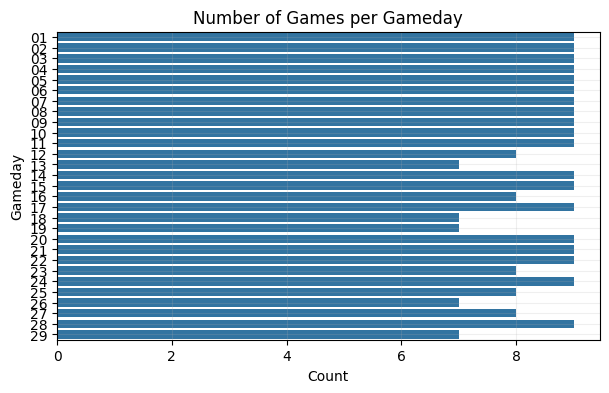

In [128]:

# extract unique gameday from list_files, where gameday is indicated as **_gd_01_** in the file name
gameday = [file.split("_gd_")[1].split("_")[0] for file in list_files]

# Plot number of games per gameday
plt.figure(figsize=(7, 4))
sns.countplot(gameday)
plt.title(f"Number of Games per Gameday")
plt.ylabel("Gameday")
plt.xlabel("Count")
plt.grid(True, "both", alpha=0.2)
plt.show()


### Number of games per team

<Figure size 1000x600 with 0 Axes>

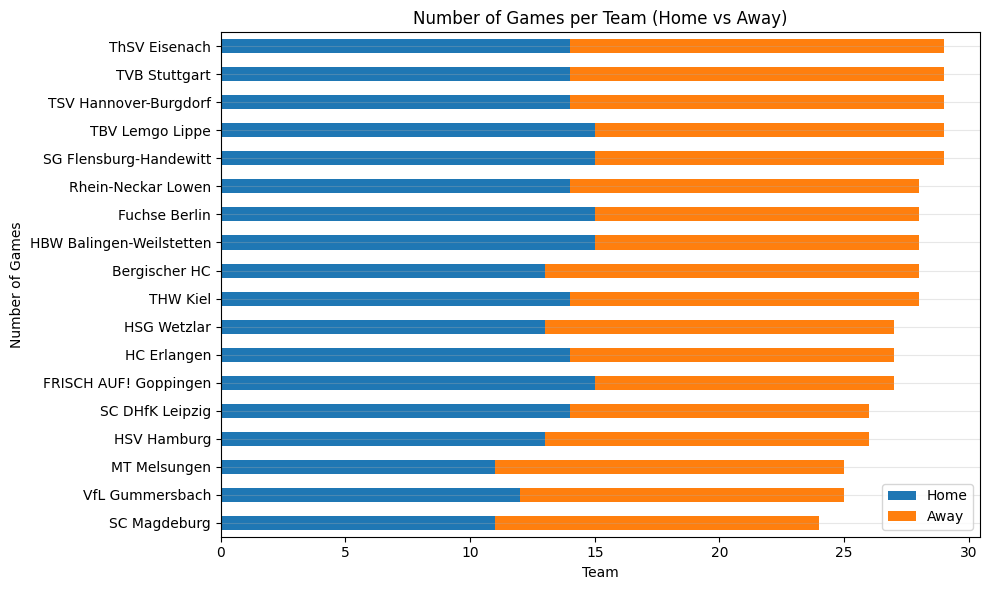

In [129]:
# Count home and away games separately
home_games = df.groupby('name_team_home')['match_id'].nunique()
away_games = df.groupby('name_team_away')['match_id'].nunique()

# Combine home and away games into one DataFrame and calculate total games
games_per_team = pd.DataFrame({'Home': home_games, 'Away': away_games}).fillna(0)
games_per_team['Total'] = games_per_team['Home'] + games_per_team['Away']

# Sort by total number of games
games_per_team = games_per_team.sort_values('Total', ascending=True)

# Plot the stacked bar chart
plt.figure(figsize=(10, 6))
games_per_team[['Home', 'Away']].plot(kind='barh', stacked=True, figsize=(10, 6))

plt.title("Number of Games per Team (Home vs Away)")
plt.ylabel("Number of Games")
plt.xlabel("Team")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()

plt.show()


In [130]:
# # Calculate the sorted order based on the count of each event type
# event_type_order = df["event_type"].value_counts().index

# # Plot the sorted histogram of event_type
# plt.figure(figsize=(10, 6))
# sns.countplot(data=df, x="event_type", order=event_type_order)  # Sort by count
# plt.title(f"Event Type Distribution for {len(df)} events")
# plt.xlabel("Event Type")
# plt.ylabel("Count")
# # grid, both axis
# plt.grid(True, "both", alpha=0.2)
# plt.show()

In [131]:
# print event_type value counts
print(df['event_type'].value_counts())
# uniquze shot_type value counts
# print(df['shot_type'].value_counts())
# # uniquze shot_type value counts
# print(df['method'].value_counts())
# print how many nans for event_time_throw
print(df['event_time_throw'].isna().value_counts())


event_type
score_change       14498
shot_saved          5098
shot_off_target     2002
shot_blocked         877
seven_m_missed       448
Name: count, dtype: int64
event_time_throw
True     12367
False    10556
Name: count, dtype: int64


### Number of rows without sync point

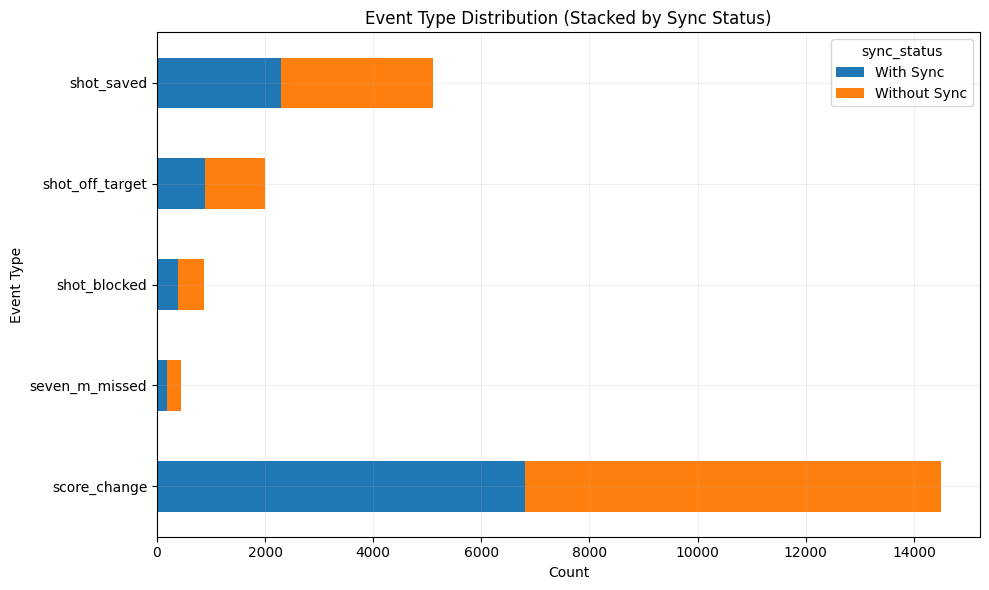

sync_status
Without Sync    12367
With Sync       10556
Name: count, dtype: int64


In [132]:
import matplotlib.pyplot as plt

# Create a new column to indicate whether an event has sync or not
df["sync_status"] = df["event_time_throw"].notna().map({True: 'With Sync', False: 'Without Sync'})

# Define the order of event types if needed
# Adjust this to your event type order if necessary
# event_type_order = ['event_type_1', 'event_type_2', ...]

# Count events for each event_type by sync_status
event_type_sync = df.groupby(['event_type', 'sync_status']).size().unstack(fill_value=0)

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plot "With Sync" and "Without Sync" stacked
event_type_sync[['With Sync', 'Without Sync']].plot(kind='barh', stacked=True, ax=ax)

# Add title and labels
ax.set_title("Event Type Distribution (Stacked by Sync Status)")
ax.set_xlabel("Count")
ax.set_ylabel("Event Type")

# Rotate x-ticks for readability
# plt.xticks(rotation=90)

# Add grid for both axes
plt.grid(True, "both", alpha=0.2)

# Show the plot
plt.tight_layout()
plt.show()

# Print the number of events with and without sync
print(df["sync_status"].value_counts())

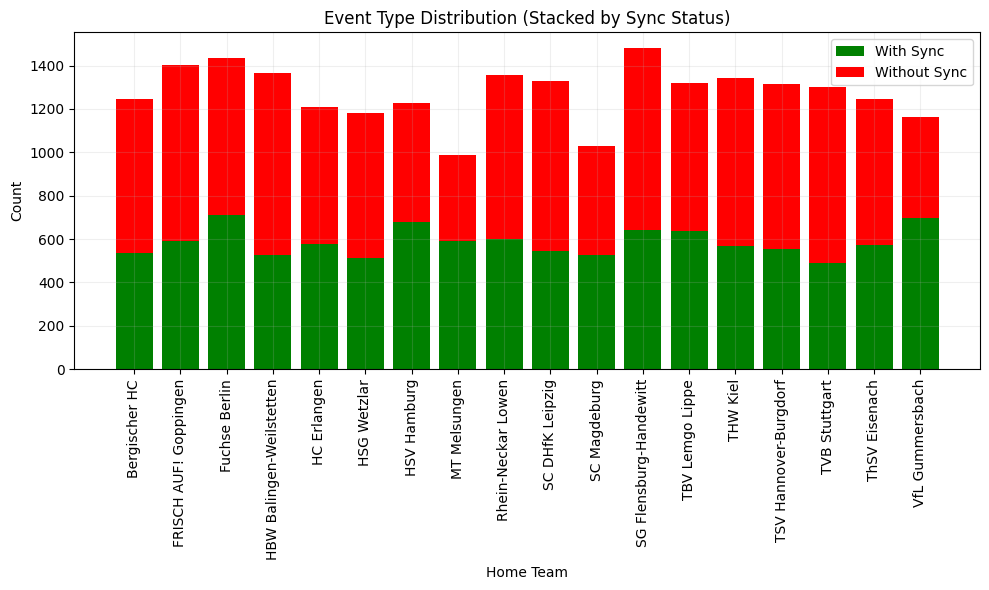

In [133]:

# Create a new column to indicate whether an event has sync or not
df["sync_status"] = df["event_time_throw"].notna().map({True: 'With Sync', False: 'Without Sync'})

# Count events for each team by sync status
event_sync_count = df.groupby(['name_team_home', 'sync_status']).size().unstack(fill_value=0)

# Plot the stacked bar chart
plt.figure(figsize=(10, 6))

# Create stacked bars for 'With Sync' and 'Without Sync'
plt.bar(event_sync_count.index, event_sync_count['With Sync'], label='With Sync', color='g')
plt.bar(event_sync_count.index, event_sync_count['Without Sync'], bottom=event_sync_count['With Sync'], label='Without Sync', color='r')

# Add title and labels
plt.title("Event Type Distribution (Stacked by Sync Status)")
plt.xlabel("Home Team")
plt.ylabel("Count")

# Rotate x-ticks for readability
plt.xticks(rotation=90)

# Add grid for both axes
plt.grid(True, "both", alpha=0.2)

# Add legend to distinguish sync status
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

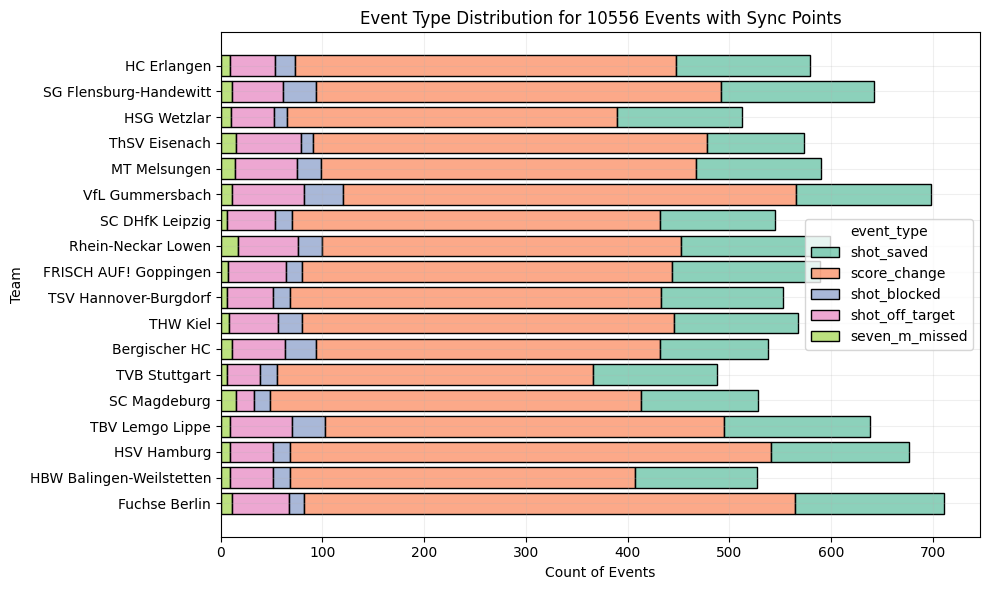

In [134]:

# Create df_sync where event_time_throw is not NaN
df_sync = df.dropna(subset=["event_time_throw"])

# Sort teams by the overall count of events (sorted already in value_counts)
team_order = df_sync['name_team_home'].value_counts().index

# Plot the stacked histogram of event_type for each team, sorted by team count
plt.figure(figsize=(10, 6))

# Create a histogram with stacked bars for each event_type
sns.histplot(data=df_sync, y="name_team_home", hue="event_type", multiple="stack", 
             palette="Set2", shrink=0.8)


# Add title and labels
plt.title(f"Event Type Distribution for {len(df_sync)} Events with Sync Points")
plt.xlabel("Count of Events")
plt.ylabel("Team")

# Add gridlines
plt.grid(True, which="both", alpha=0.2)

# Rotate y-axis labels for better readability
plt.yticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()

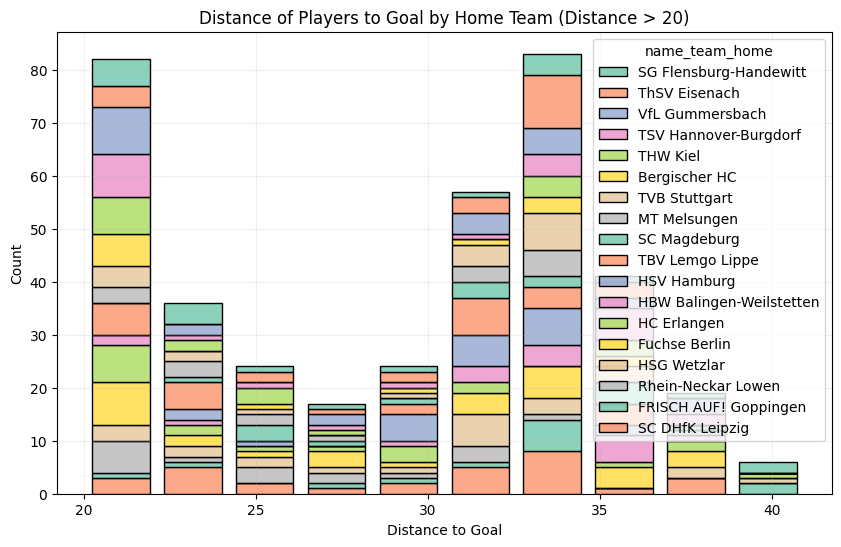

name_team_home
Fuchse Berlin               32
SC DHfK Leipzig             30
TBV Lemgo Lippe             28
VfL Gummersbach             27
TSV Hannover-Burgdorf       25
ThSV Eisenach               25
HSV Hamburg                 24
TVB Stuttgart               22
HSG Wetzlar                 21
SG Flensburg-Handewitt      21
THW Kiel                    20
HC Erlangen                 20
MT Melsungen                17
HBW Balingen-Weilstetten    17
Rhein-Neckar Lowen          17
SC Magdeburg                16
Bergischer HC               14
FRISCH AUF! Goppingen       13
Name: count, dtype: int64


In [135]:
# show distribution of name_team_home and distance_player_to_goal
plt.figure(figsize=(10, 6))
sns.histplot(data=df[df['distance_player_to_goal'] > 20], x="distance_player_to_goal", hue="name_team_home", multiple="stack", palette="Set2", shrink=0.8)
plt.title("Distance of Players to Goal by Home Team (Distance > 20)")
plt.xlabel("Distance to Goal")
plt.ylabel("Count")
plt.grid(True, alpha=0.2)
plt.show()

# print sorted value counts of name_team_home with distance_player_to_goal > 20
print(df[df['distance_player_to_goal'] > 20]['name_team_home'].value_counts())


In [136]:
# show which match_id have the most events without sync, but print only the top 10
print(df[df['event_time_throw'].isna()]['match_id'].value_counts().tail(10))


match_id
42307591    2
42307603    2
42307937    2
42307777    1
42307535    1
42307543    1
42307575    1
42307577    1
42307941    1
42307433    1
Name: count, dtype: int64


In [137]:
features = [
    "distance_player_to_goal",  # distance between player and the goal
    "distance_player_to_goalkeeper",  # distance between player and goalkeeper
    "distance_goalkeeper_to_goal",  # distance between goalkeeper and goal
    "angle_player_to_goal",  # angle of the ball relative to the goal
    # "angle_ball_to_goal",
    # "speed_ball",  # speed of the ball when thrown
    "speed_player",  # speed of the player
    "distance_player_to_nearst_opponent",  # distance to the nearest defender
    "distance_player_to_nearest_teammate",  # number of defenders close to the player
    "num_opponents_between_player_and_goal",  # number of defenders between player and goal
    "num_opponents_close_to_player",  # number of defenders close to the player
    "efficiency_shots_team",  # efficiency of the team in scoring goals
    "efficiency_shots_player",  # efficiency of the player in scoring goals
    "efficiency_goalkeeper",  # efficiency of the goalkeeper in saving goals
    # "method",  # method of throwing the ball
    # "zone", # zone of the field where the event occurred
    # "shot_type",  # type of shot
    # "home_advantage",  # home advantage
]

target_column = "event_type"  # target column to predict


df_features = df[features].copy()

df_features["target"] = df["event_type"].apply(
    lambda x: 1 if x == "score_change" else 0
)

df_features["target_as_string"] = df["event_type"]

# print number of "method" unique values
# print(f'Number of unique values in "method" column: {df_features["method"].nunique()}')
    


### Filtering

22923
Before dropping NaNs

Total number of rows: 22923

distance_player_to_goal                  12367
distance_player_to_goalkeeper            12977
distance_goalkeeper_to_goal              12977
angle_player_to_goal                     12367
speed_player                             12438
distance_player_to_nearst_opponent           0
distance_player_to_nearest_teammate          0
num_opponents_between_player_and_goal    12367
num_opponents_close_to_player                0
efficiency_shots_team                        0
efficiency_shots_player                    123
efficiency_goalkeeper                      632
target                                       0
target_as_string                             0
dtype: int64


C:\Users\madam\AppData\Local\Temp\ipykernel_31464\3661254990.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")


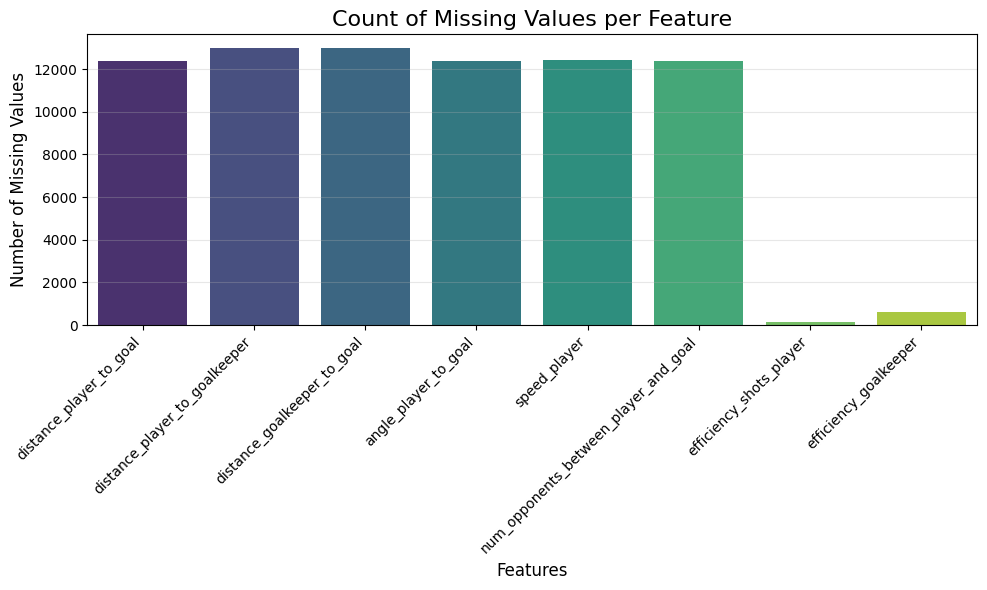

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display the shape and count of NaNs
print(df_features.shape[0])
print(f'Before dropping NaNs\n')
print(f'Total number of rows: {df_features.shape[0]}\n')
print(df_features.isnull().sum())

# Calculate the number of missing values per column
missing_values = df_features.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Filter out columns with no missing values

# Plot a bar chart for missing values
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette="viridis")

# Add titles and labels
plt.title("Count of Missing Values per Feature", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Number of Missing Values", fontsize=12)

# Rotate the x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add gridlines for clarity
plt.grid(True, axis="y", alpha=0.3)

# Display the plot
plt.tight_layout()
plt.show()


# Analysis

### Histogram of feature values

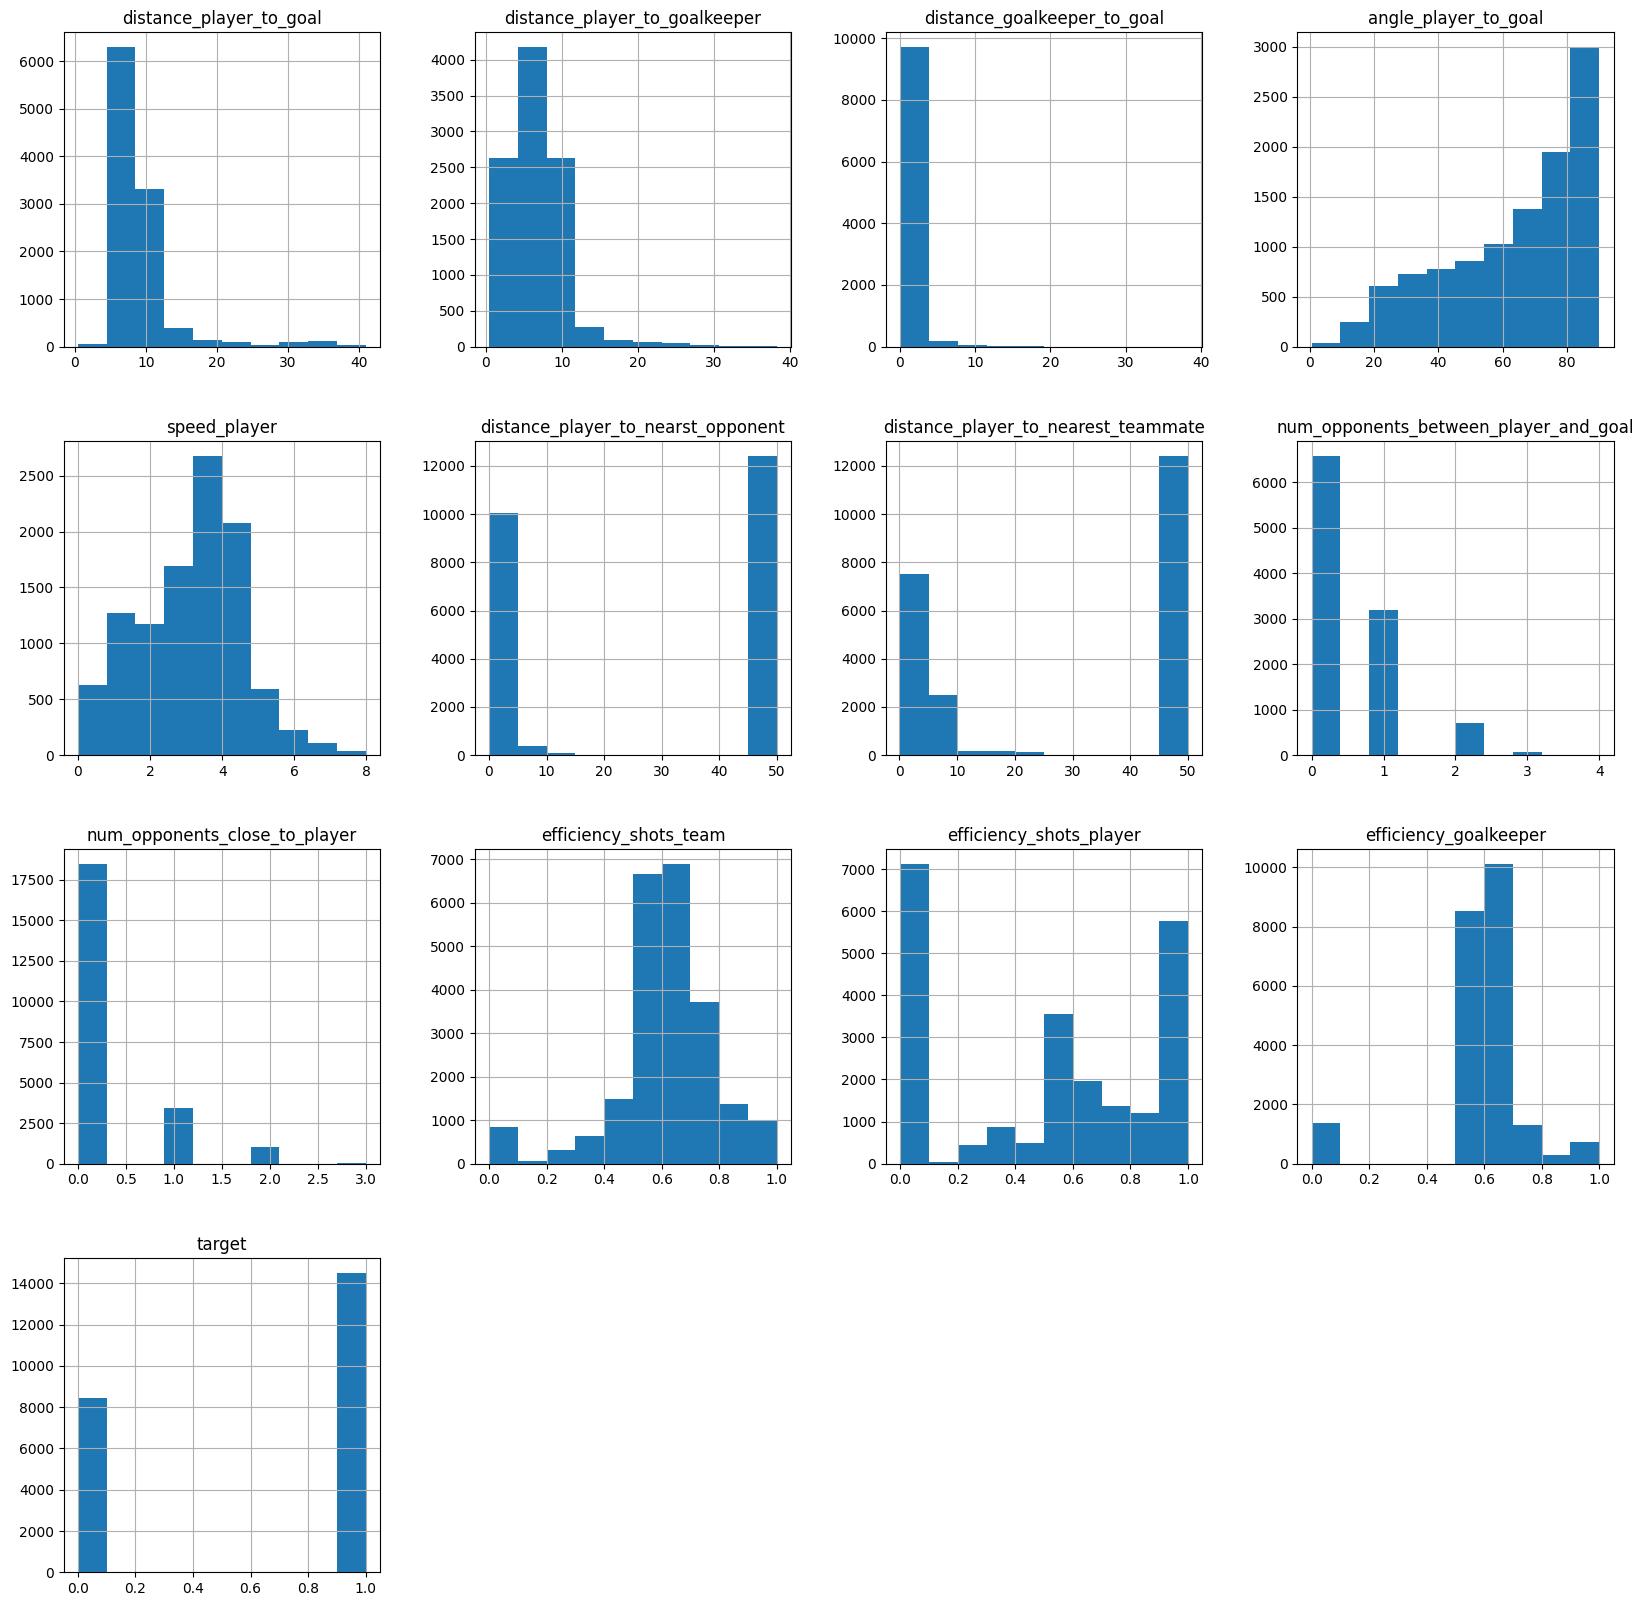

In [139]:
# plot hist of features
df_features.hist(figsize=(20, 20))
plt.show()

C:\Users\madam\AppData\Local\Temp\ipykernel_31464\1758200860.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nan_counts.index, y=nan_counts.values, palette='viridis')
C:\Users\madam\AppData\Local\Temp\ipykernel_31464\1758200860.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


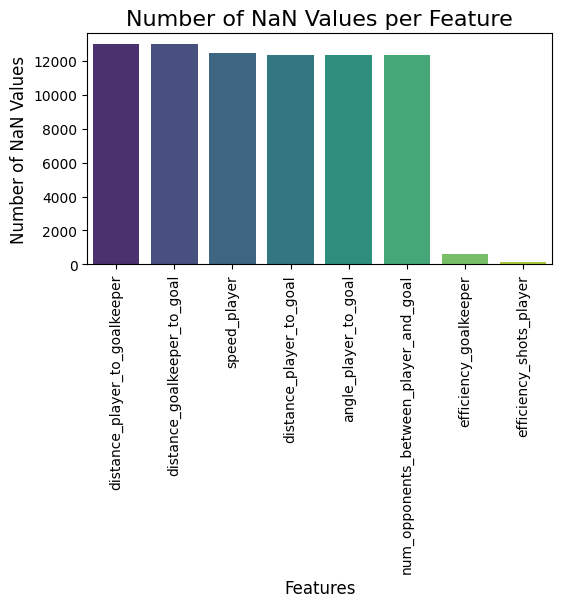

In [140]:
#  Plot NaN histogram
# Count the number of NaN values per feature
nan_counts = df_features.isnull().sum()

# Sort the NaN counts in descending order (optional for better visualization)
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

# Plot the NaN counts as a bar plot
plt.figure(figsize=(6, 3))
sns.barplot(x=nan_counts.index, y=nan_counts.values, palette='viridis')

# Rotate the x labels for better readability
plt.xticks(rotation=90)

# Add labels and title
plt.xlabel("Features", fontsize=12)
plt.ylabel("Number of NaN Values", fontsize=12)
plt.title("Number of NaN Values per Feature", fontsize=16)

# Show the plot
plt.tight_layout()
plt.show()


### Dropping unrealistic values

C:\Users\madam\AppData\Local\Temp\ipykernel_31464\375221409.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=nan_events, x="name_team_home", palette="viridis")


12367


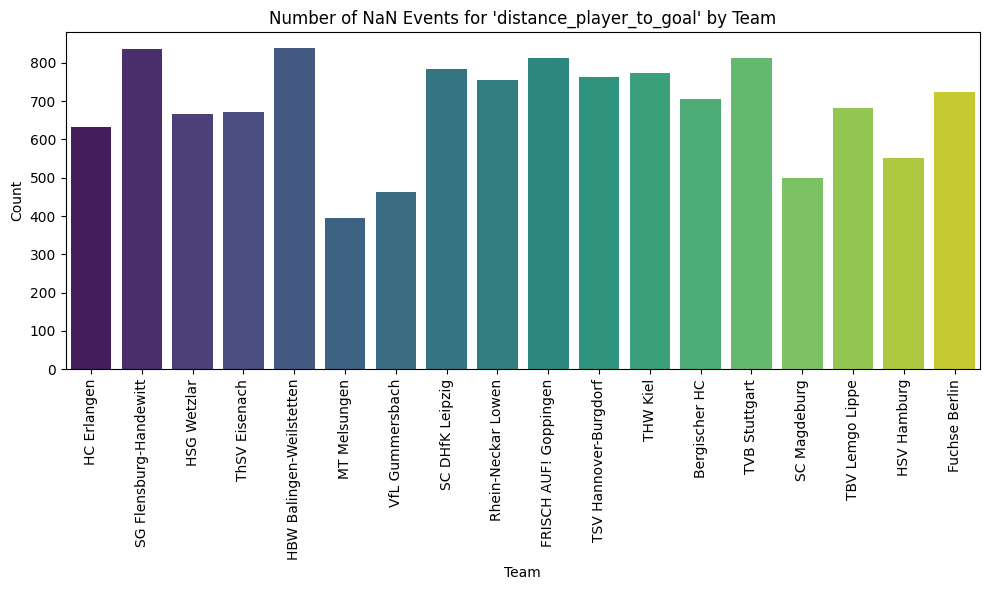

In [141]:
# Merge 'name_team_home' into df_features if not already present
df_features['name_team_home'] = df['name_team_home']

# Filter rows where 'distance_player_to_goal' is NaN
nan_events = df_features[df_features['distance_player_to_goal'].isna()]

print(nan_events.shape[0])  

# Ensure no NaN values exist in 'name_team_home'
nan_events = nan_events.dropna(subset=['name_team_home'])

# print(nan_events.head())

# Plot the histogram of NaN events for 'distance_player_to_goal' by team
plt.figure(figsize=(10, 6))
sns.countplot(data=nan_events, x="name_team_home", palette="viridis")

# Add titles and labels
plt.title("Number of NaN Events for 'distance_player_to_goal' by Team")
plt.xlabel("Team")
plt.ylabel("Count")

# Rotate x-axis labels for readability
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()


df_features.drop(columns=['name_team_home'], inplace=True)

In [142]:
# drop rows with NaN values
df_features = df_features.dropna()
print(f'Size of df_features after dropping NaNs: {df_features.shape[0]}\n')
# drop rows with distance_player_to_goal > 20
df_features = df_features[df_features['distance_player_to_goal'] <= 20]
print(f'Size of df_features after dropping distance_player_to_goal > 20: {df_features.shape[0]}\n')

# drop rows with distance_player_to_goalkeeper > 20
df_features = df_features[df_features['distance_player_to_goalkeeper'] <= 20]
print(f'Size of df_features after dropping distance_player_to_goalkeeper > 20: {df_features.shape[0]}\n')

# drop rows with distance_goalkeeper_to_goal > 15
df_features = df_features[df_features['distance_goalkeeper_to_goal'] <= 15]
print(f'Size of df_features after dropping distance_goalkeeper_to_goal > 15: {df_features.shape[0]}\n')


Size of df_features after dropping NaNs: 9869

Size of df_features after dropping distance_player_to_goal > 20: 9698

Size of df_features after dropping distance_player_to_goalkeeper > 20: 9697

Size of df_features after dropping distance_goalkeeper_to_goal > 15: 9696



In [143]:
# Add target column because we want to see if it correlates with the features
# target is 1 if the event is a event_type is "score_change", 0 otherwise

# Correlation matrix for df_features but without the target_as_string column
corr = df_features.drop(columns=["target_as_string", "shot_type", "method", "zone"]).corr()
# Correlation matrix
# corr = df_features.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
)

plt.show()

# print most correlated features
print(corr["target"].sort_values(ascending=False))


KeyError: "['shot_type', 'method', 'zone'] not found in axis"

###  Feature Importance with a Tree-Based Model

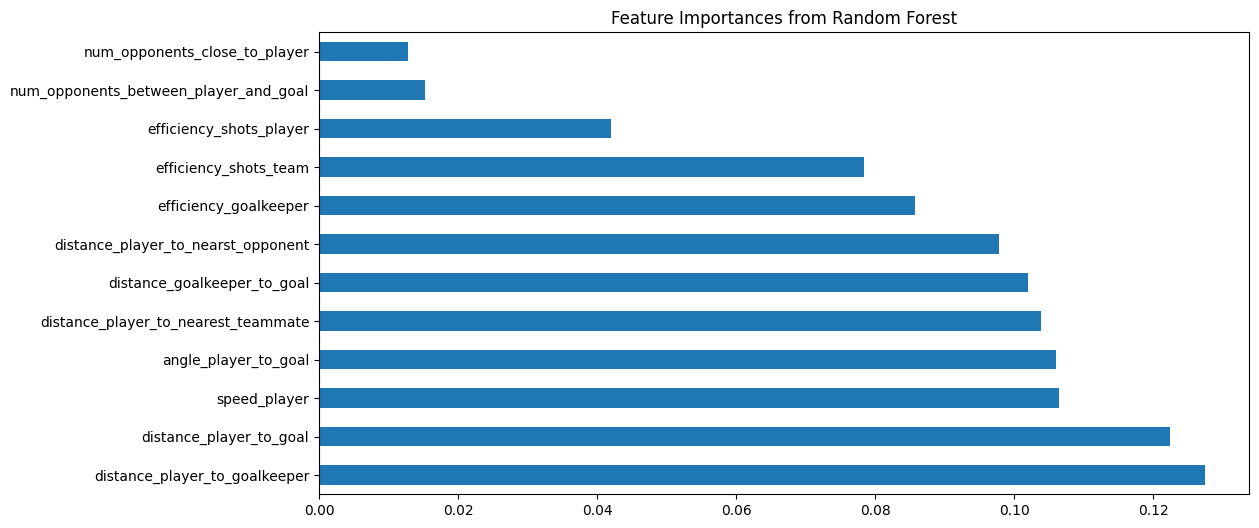

In [146]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Define the feature columns (excluding the target)
# feature_columns = df_features.drop("target", axis=1).drop("target_as_string", axis=1).drop("shot_type", axis=1).drop("method", axis=1).drop("zone", axis=1).columns

feature_columns = df_features.drop("target", axis=1).drop("target_as_string", axis=1).columns

# Train a Random Forest model to check feature importance
X = df_features[feature_columns]
y = df_features["target"]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importance
feature_importances = pd.Series(model.feature_importances_, index=feature_columns)

# Sort and plot feature importances
feature_importances.sort_values(ascending=False).plot(kind="barh", figsize=(12, 6))
plt.title("Feature Importances from Random Forest")
plt.show()


### is there mutual information?

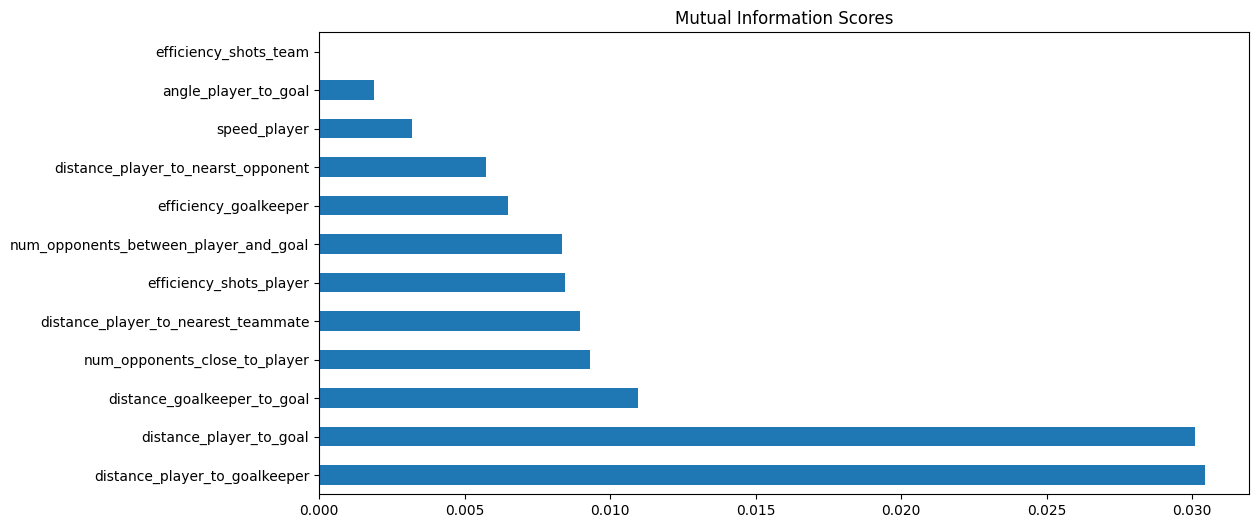

In [147]:
from sklearn.feature_selection import mutual_info_classif

# Compute the mutual information between each feature and the target
mi = mutual_info_classif(X, y)

# Create a DataFrame for better visualization
mi_series = pd.Series(mi, index=feature_columns)
mi_series.sort_values(ascending=False).plot(kind="barh", figsize=(12, 6))
plt.title("Mutual Information Scores")
plt.show()


### Variance Threshold (Detecting Low-Variance Features)

In [148]:
from sklearn.feature_selection import VarianceThreshold

# Apply a variance threshold to remove features with low variance
selector = VarianceThreshold(threshold=0.1)  # Choose an appropriate threshold
selector.fit(X)

# Get the remaining features
remaining_features = X.columns[selector.get_support()]
print(f"Features retained after variance threshold: {list(remaining_features)}")
# print features that were dropped
print(f"Features dropped after variance threshold: {list(X.columns[~selector.get_support()])}")


Features retained after variance threshold: ['distance_player_to_goal', 'distance_player_to_goalkeeper', 'distance_goalkeeper_to_goal', 'angle_player_to_goal', 'speed_player', 'distance_player_to_nearst_opponent', 'distance_player_to_nearest_teammate', 'num_opponents_between_player_and_goal', 'num_opponents_close_to_player', 'efficiency_shots_player']
Features dropped after variance threshold: ['efficiency_shots_team', 'efficiency_goalkeeper']


### Multicollinearity

In [149]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = feature_columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(feature_columns))]

# Print VIF data
print(vif_data.sort_values(by="VIF", ascending=False))


                                  Feature         VIF
0                 distance_player_to_goal  497.742737
1           distance_player_to_goalkeeper  322.827503
2             distance_goalkeeper_to_goal   30.225683
9                   efficiency_shots_team   11.166601
11                  efficiency_goalkeeper   10.362355
3                    angle_player_to_goal    9.835058
4                            speed_player    6.015513
5      distance_player_to_nearst_opponent    5.222398
6     distance_player_to_nearest_teammate    4.056192
10                efficiency_shots_player    2.833307
7   num_opponents_between_player_and_goal    2.230295
8           num_opponents_close_to_player    2.213182


###  Feature Distributions and Target Separation (Boxplots and KDEs)

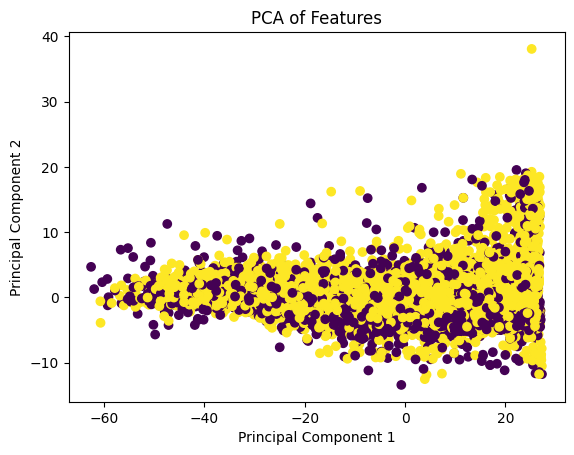

In [150]:
from sklearn.decomposition import PCA

# Apply PCA and plot the first two components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

plt.scatter(pca_result[:, 0], pca_result[:, 1], c=y, cmap='viridis')
plt.title("PCA of Features")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


# Density plots of features

# Distance

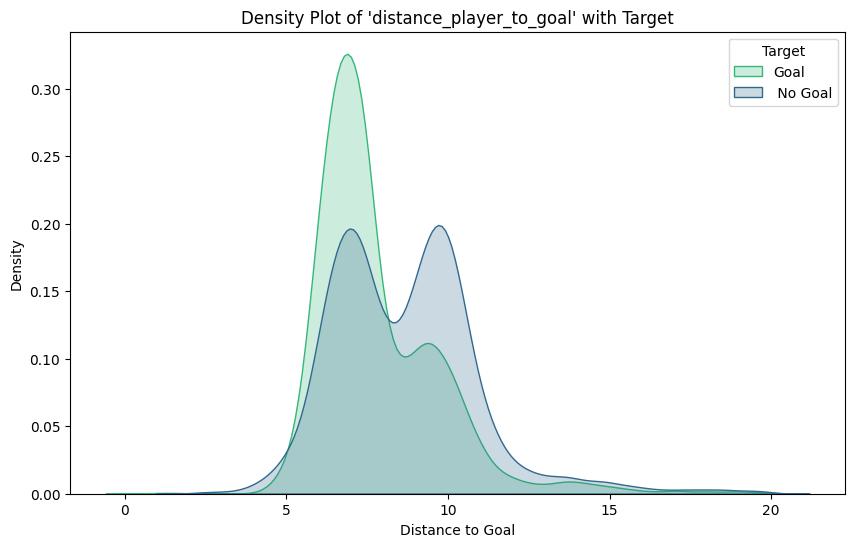

In [151]:
# Density plot of feature distance with target (kde plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_features, x="distance_player_to_goal", hue="target", fill=True, common_norm=False, palette="viridis")

plt.title("Density Plot of 'distance_player_to_goal' with Target")
plt.xlabel("Distance to Goal")
plt.ylabel("Density")
# legend is 0 no goal and 1 goal
plt.legend(title="Target", labels=["Goal", " No Goal"])
plt.show()


In [153]:
# # density plot for distance_player_to_goalkeeper, but without the method == "penalty"
# # first print the number of rows with method == "penalty"
# print(f'Number of rows with method == "penalty": {df_features[df_features["method"] == "penalty"].shape[0]}')
# plt.figure(figsize=(10, 6))
# sns.kdeplot(data=df_features[df_features["method"] != "penalty"], x="distance_player_to_goalkeeper", hue="target", fill=True, common_norm=False, palette="viridis")
# plt.title("Density Plot of 'distance_player_to_goalkeeper' with Target (excluding penalties)")
# plt.xlabel("Distance to Goalkeeper")
# plt.ylabel("Density")
# plt.legend(title="Target", labels=["Goal", " No Goal"])


# Training

### Preparing data

In [154]:
# filter out penalties
# df_features = df_features[df_features["method"] != "penalty"]

In [156]:
for col in df_features.columns:
    print(col)

# drop target_as_string column
df_features.drop(columns=['target_as_string'], inplace=True)
# drop method, zone, shot_type columns
# df_features.drop(columns=['method', 'zone', 'shot_type'], inplace=True)

distance_player_to_goal
distance_player_to_goalkeeper
distance_goalkeeper_to_goal
angle_player_to_goal
speed_player
distance_player_to_nearst_opponent
distance_player_to_nearest_teammate
num_opponents_between_player_and_goal
num_opponents_close_to_player
efficiency_shots_team
efficiency_shots_player
efficiency_goalkeeper
target


KeyError: "['target_as_string'] not found in axis"

In [157]:

# Select the features and target column
X = df_features[feature_columns]
y = df_features["target"]

print(y.value_counts())




target
1    6222
0    3474
Name: count, dtype: int64


### Apply RandomUndersampling

In [158]:
# sampling_strategy = 1
# rus = RandomUnderSampler(sampling_strategy=sampling_strategy)
# X_res, y_res = rus.fit_resample(X, y)

# # print distribution of target column
# print(y_res.value_counts())

In [159]:
X_res = X
y_res = y


### Train-Test-Splits

In [160]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

NameError: name 'train_test_split' is not defined

### Paths and algorithms for automl

In [ ]:
path_out = "../data/ml_stuff/automl_11"

algorithms=[
    "Xgboost",
    "CatBoost",
    "Random Forest",
]

### Train automl

In [ ]:
# automl = AutoML(
#     results_path=path_out,
#     algorithms=[
#         "Xgboost",
#         "CatBoost",
#         "Random Forest",
#     ],
#     total_time_limit=5 * 60,
#     # n_jobs=6,
#     explain_level=2,
#     mode="Explain",
#     random_state=42,
    
# )

automl = AutoML(
    results_path=path_out,
    algorithms=[
        "Xgboost",
        "CatBoost",
        "Random Forest",
    ],
    total_time_limit=5 * 60,
    # n_jobs=6,
    explain_level=2,
    mode="Explain",
    random_state=42,
    
)

### Fit

In [ ]:
automl.fit(X_train, y_train)

### Test

In [ ]:
# Predict the target values
y_pred = automl.predict(X_test)

# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Print the evaluation metrics
print(f"\nAccuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")


# plot the confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


### Columns of feature

In [ ]:
# print all columns of the dataframe
for col in df_features.columns:
    print(col)

### Now apply model on complete dataframe

In [ ]:
# Now apply model on complete dataframe and insert column "xG"
X = df_features[feature_columns]
y = df_features["target"]

# Predict the target values
y_pred = automl.predict(X)
# get proba
y_pred = automl.predict_proba(X)[:, 1]

# insert column "xG" into df_features
df_features["xG"] = y_pred

# print some xG
print(df_features["xG"].value_counts())

# insert xG of df_features into df
df["xG"] = df_features["xG"]
# and target
df["target"] = df_features["target"]

### Plot positions and xG

In [ ]:

# Create a figure and axis for the histogram
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the histogram with stacking based on target (score change)
sns.histplot(data=df, x="xG", bins=50, hue="target", multiple="stack", palette="Set1", stat="count", ax=ax1)

# Set labels and grid for the first y-axis (counts)
ax1.set_title("xG Distribution (Stacked by Score Change) with Density Lines")
ax1.set_xlabel("xG")
ax1.set_ylabel("Count")
ax1.grid(True, "both", alpha=0.2)

# Create a second y-axis for the density
ax2 = ax1.twinx()

# Add density lines for both score change == 0 and score change == 1 on the second y-axis
sns.kdeplot(data=df[df["target"] == 0], x="xG", color="red", label="Density (No Score Change)", ax=ax2, lw=2)
sns.kdeplot(data=df[df["target"] == 1], x="xG", color="blue", label="Density (Score Change)", ax=ax2, lw=2)

# Set label for the second y-axis (density)
ax2.set_ylabel("Density")

# Show legends for the density lines
ax2.legend(loc="upper left")

# Show the plot
plt.show()

In [ ]:
df_plot = df.copy()
# group by name_team_home and calculate mean y position

# plot positions and xG
plt.figure(figsize=(10, 6))
# assets\handballfeld.png
img = plt.imread("../assets/handballfeld.png")
plt.imshow(img, extent=[0, 40, 0, 20])
plt.scatter(df["pos_x_player"], df["pos_y_player"], c=df["xG"], cmap="coolwarm")
plt.colorbar()
plt.title("xG of Throws")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.show()

# display
display(df.head())


In [ ]:
# Group by player and calculate the sum of xG and goals, and count the number of throws
df_grouped = df.groupby("name_player")[["xG", "target"]].agg(['sum', 'count']).reset_index()

# Flatten the multi-index columns
df_grouped.columns = ["name_player", "xG_sum", "goal_sum", "xG_count", "goal_count"]

# Normalize the xG and goals by dividing by the number of throws (using the count for xG or target)
# df_grouped["xG_normalized"] = df_grouped["xG_sum"] / len(df_grouped)
# df_grouped["goal_normalized"] = df_grouped["goal_sum"] / len(df_grouped)

# sort by xG sum
df_grouped = df_grouped.sort_values(by="goal_count", ascending=True)
# drop players with less than 10 throws
df_grouped = df_grouped[df_grouped["goal_count"] > 30]

# Display the dataframe to check the results
display(df_grouped.head())

# Plot xG sum vs. goal sum (both normalized)
plt.figure(figsize=(10, 10))
plt.scatter(df_grouped["xG_sum"], df_grouped["goal_sum"], color='blue', alpha=0.7)
plt.title("Normalized xG Sum vs Normalized Goal Sum")
plt.xlabel("Normalized xG")
plt.ylabel("Normalized Goals")
# make axis equal
# plt.axis('equal')
# bot start at 0
plt.xlim(0, 70)
plt.ylim(0.0, 70)
plt.grid(True)
plt.show()


### Print information about the xG, which teams are the best atm?

In [ ]:

# Aggregate xG and actual goals (target) for each team
df_team_stats = df.groupby("name_team_home").agg(
    total_xG=("xG", "sum"),
    total_goals=("target", "sum")
).reset_index()

# Melt the DataFrame to a long format for easier plotting
df_melted = pd.melt(df_team_stats, id_vars=["name_team_home"], value_vars=["total_xG", "total_goals"],
                    var_name="Metric", value_name="Value")

# Sort the teams by xG or total goals
df_team_stats = df_team_stats.sort_values(by="total_xG", ascending=False)

# Plot the xG and actual goals side by side for each team
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x="name_team_home", y="Value", hue="Metric", palette="Blues_d")

# Add title and labels
plt.title("Total xG and Actual Goals by Home Team", fontsize=16)
plt.xlabel("Team", fontsize=12)
plt.ylabel("Total Value", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Add gridlines for the y-axis
plt.grid(True, which="both", axis="y", alpha=0.3)

# Show the plot
plt.show()

In [ ]:
# # Assuming 'num_events' represents the number of matches or events for each team
# df_team_stats["num_events"] = df["name_team_home"].value_counts()

# display(df_team_stats)
# # transform df_team_stats["num_events"] to int
# df_team_stats["num_events"] = df_team_stats["num_events"].astype(int)

# df_team_stats["xG_per_event"] = df_team_stats["total_xG"] / df_team_stats["num_events"]
# df_team_stats["goals_per_event"] = df_team_stats["total_goals"] / df_team_stats["num_events"]

# # Melt the DataFrame to a long format for easier plotting
# df_melted = pd.melt(df_team_stats, id_vars=["name_team_home"], value_vars=["xG_per_event", "goals_per_event"],
#                     var_name="Metric", value_name="Value")

# # Plot normalized xG vs normalized goals
# plt.figure(figsize=(12, 6))
# sns.scatterplot(data=df_team_stats, x="xG_per_event", y="goals_per_event", hue="name_team_home", s=100)

# # Add title and labels
# plt.title("Normalized xG vs Actual Goals by Home Team (Per Event)", fontsize=16)
# plt.xlabel("Normalized xG (Per Event)", fontsize=12)
# plt.ylabel("Normalized Goals (Per Event)", fontsize=12)

# # Add 1:1 line
# plt.plot([0, df_team_stats["xG_per_event"].max()], [0, df_team_stats["goals_per_event"].max()], color="red", linestyle="--", linewidth=2)

# # Adjust axis limits based on normalized values
# plt.xlim(0, df_team_stats["xG_per_event"].max() + 0.1)
# plt.ylim(0, df_team_stats["goals_per_event"].max() + 0.1)

# # Add gridlines
# plt.grid(True, which="both", alpha=0.3)

# # Show the plot
# plt.show()


In [ ]:
# plot xG vs actual goals
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_team_stats, x="total_xG", y="total_goals", hue="name_team_home", s=100)

# Add title and labels
plt.title("Total xG vs Actual Goals by Home Team", fontsize=16)
plt.xlabel("Total xG", fontsize=12)
plt.ylabel("Total Goals", fontsize=12)

# make axis equal and add 1:1 line
# plt.axis("equal")
plt.plot([0, 300], [0, 300], color="red", linestyle="--", linewidth=2)

# limits to 0-300
plt.xlim(150, 300)
plt.ylim(150, 300)

# Add gridlines
plt.grid(True, which="both", alpha=0.3)

# Show the plot
plt.show()
